In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("/content/ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Basic Exploration

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [7]:
df.shape

(10000, 14)

## **Check missing values**

In [8]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


**EDA**

**Target distribution**

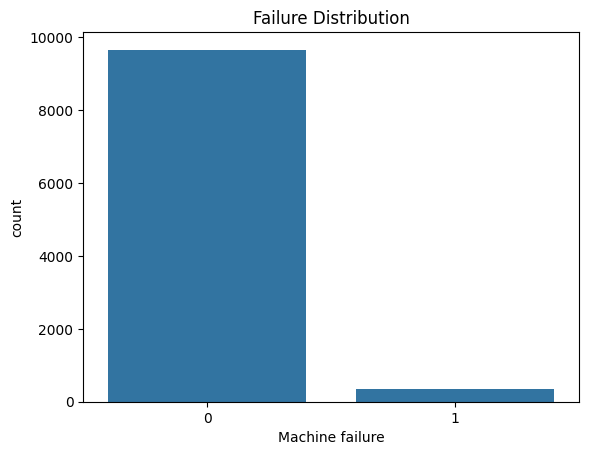

In [9]:
sns.countplot(x='Machine failure', data=df)
plt.title('Failure Distribution')
plt.show()

## **Correlation heatmap**

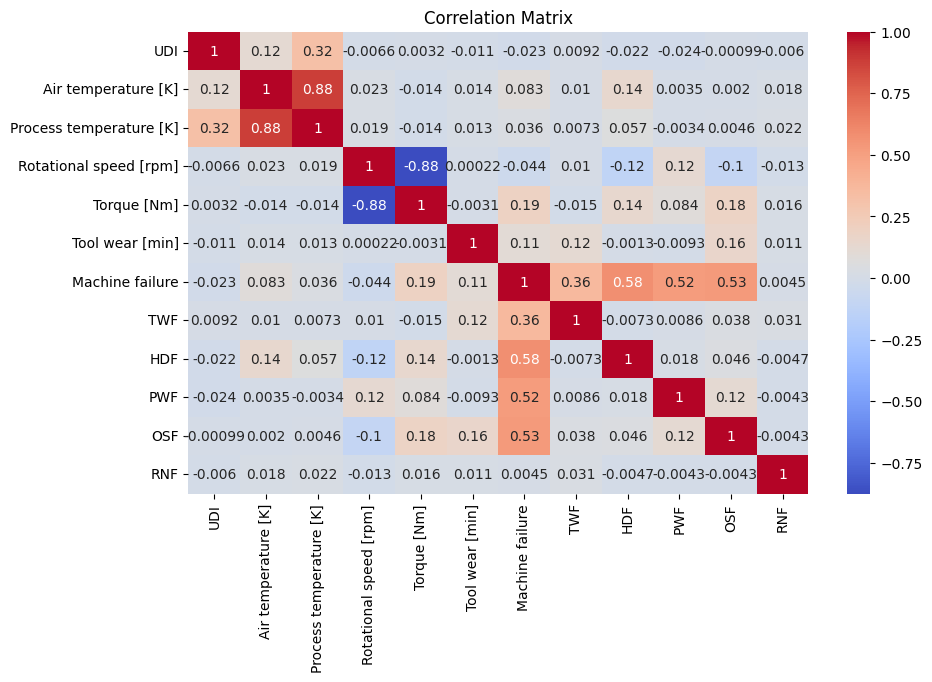

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## **Feature vs target**

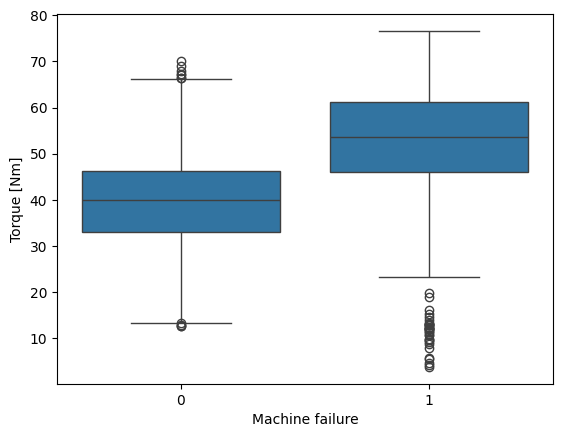

In [11]:
sns.boxplot(x='Machine failure', y='Torque [Nm]', data=df)
plt.show()

# **Data Preprocessing**
## **Drop useless columns**

In [12]:
df = df.drop(['UDI', 'Product ID'], axis=1)

## **Encode Type**

In [13]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])

## **Feature Engineering**

In [14]:
df['Temp_diff'] = df['Process temperature [K]'] - df['Air temperature [K]']

# **Handle Class Imbalance**

In [15]:
X = df.drop('Machine failure', axis=1)
y = df['Machine failure']

print(y.value_counts())

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

Machine failure
0    9661
1     339
Name: count, dtype: int64
Machine failure
0    9661
1    9661
Name: count, dtype: int64


# **Train-Test Split + Scaling**

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training**
## **Logistic Regression (Baseline)**

In [17]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

## **Random Forest**

In [18]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## **XGBoost**

In [19]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

# **Model Evaluation**

--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.90      0.96      0.93      1934
           1       0.95      0.89      0.92      1931

    accuracy                           0.92      3865
   macro avg       0.92      0.92      0.92      3865
weighted avg       0.92      0.92      0.92      3865



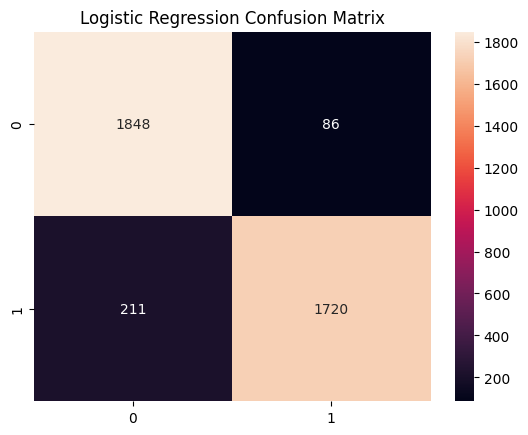

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1934
           1       0.99      0.98      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



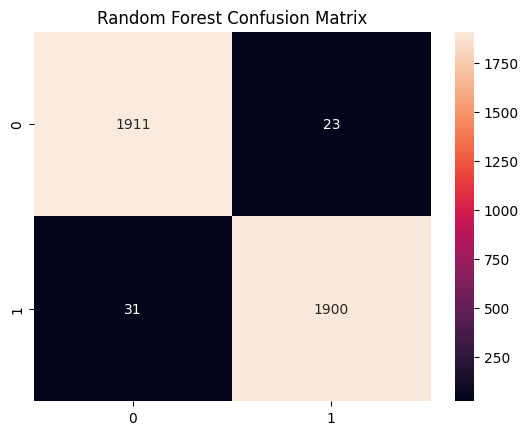

--- XGBoost ---
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1934
           1       0.99      0.99      0.99      1931

    accuracy                           0.99      3865
   macro avg       0.99      0.99      0.99      3865
weighted avg       0.99      0.99      0.99      3865



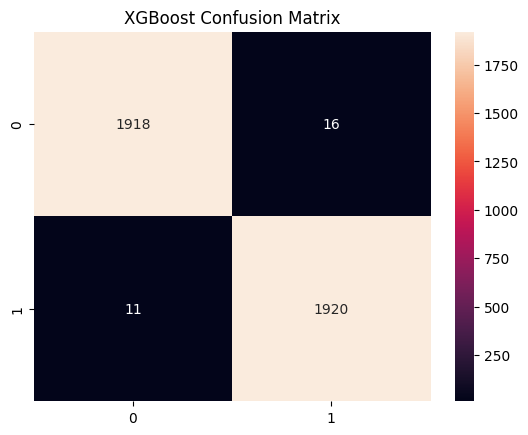

In [20]:
def evaluate_model(name, y_test, y_pred):
    print(f"--- {name} ---")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'{name} Confusion Matrix')
    plt.show()

evaluate_model("Logistic Regression", y_test, y_pred_lr)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("XGBoost", y_test, y_pred_xgb)

# **ROC Curve**

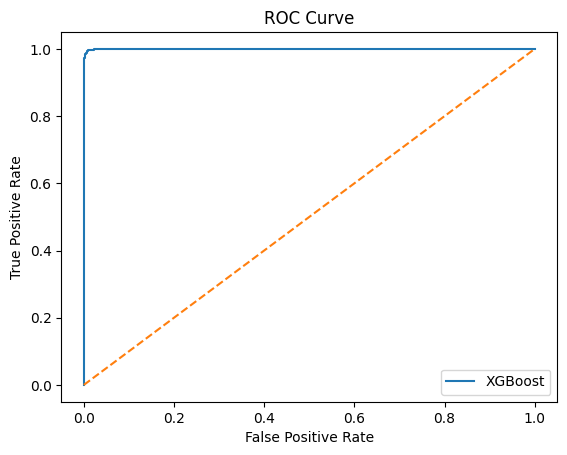

ROC-AUC Score: 0.9997255361684421


In [21]:
y_prob = xgb.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="XGBoost")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))

# **Explainable AI**

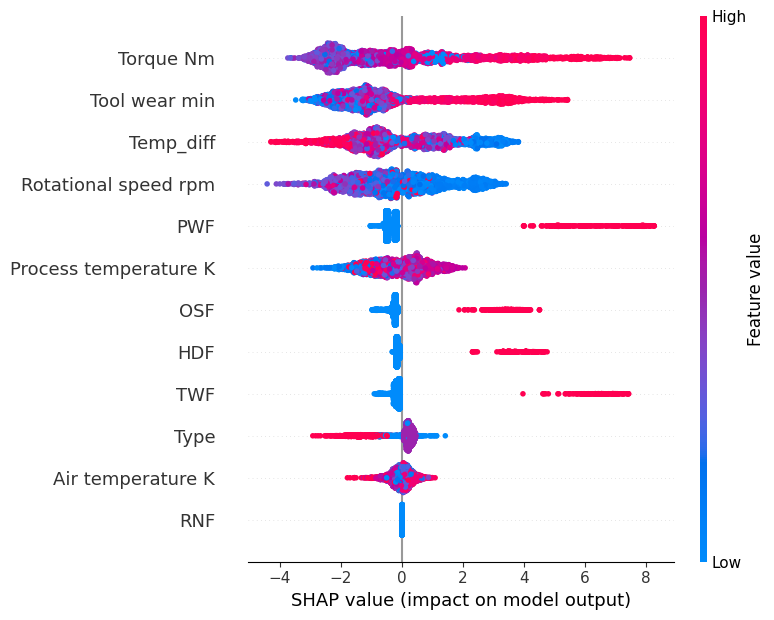

In [22]:
clean_columns = [c.replace('[', '').replace(']', '').replace('<', 'lt') for c in X.columns]

X_test_df = pd.DataFrame(X_test, columns=clean_columns)

explainer = shap.Explainer(xgb, feature_names=clean_columns)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

# **Feature Importance**

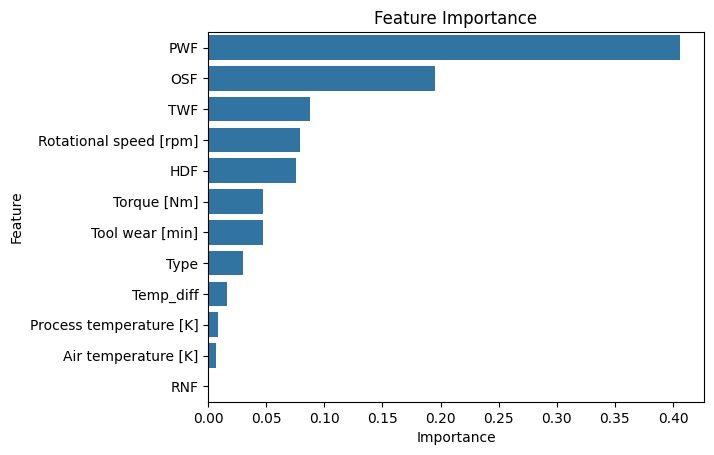

In [23]:
importances = xgb.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title('Feature Importance')
plt.show()

In [25]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# ==========================================
# 1. LOAD ORIGINAL PREDICTIONS
# ==========================================
print("Loading predictions_with_decisions (1).csv...")
try:
    df = pd.read_csv('predictions_with_decisions (1).csv')
    # Round Failure Probability as requested to 4 decimal places
    if 'Failure_Probability' in df.columns:
        df['Failure_Probability'] = df['Failure_Probability'].round(4)
except FileNotFoundError:
    print("Error: Could not find 'predictions_with_decisions (1).csv'. Please make sure it is in the same folder.")
    exit()

# ==========================================
# 2. SIMPLE TIME LOGIC (Runtime & Downtime Only)
# ==========================================
np.random.seed(42) # Keeps random numbers consistent

# 1. RUNTIME: How long did the machine actually run?
# If normal: Ran for 100-300 hours perfectly.
# If failed: Ran for 1-10 hours before it suddenly broke.
df['Runtime Hours'] = np.where(
    df['Actual_Machine_failure'] == 0,
    np.random.randint(100, 300, size=len(df)),
    np.random.randint(1, 10, size=len(df))
)

# 2. DOWNTIME: How long was it broken?
# If normal: 0 hours broken.
# If failed: Took 2-8 hours to fix.
df['Downtime Hours'] = np.where(
    df['Actual_Machine_failure'] == 1,
    np.random.randint(2, 8, size=len(df)),
    0
)

# Total Elapsed Time (Used only to calculate correct dates later)
df['Total Elapsed Time'] = df['Runtime Hours'] + df['Downtime Hours']

# ==========================================
# 3. CYCLE TIME & PRODUCTION UNITS (With Speed Loss)
# ==========================================
# Product Quality: 0.0=High, 2.0=Medium, 1.0=Low
cycle_conditions = [df['Type'] == 0.0, df['Type'] == 2.0, df['Type'] == 1.0]
df['Ideal cycle time [min/unit]'] = np.select(cycle_conditions, [12, 5, 2], default=5)

# Expected units per hour
df['Expected units per hour'] = (60 / df['Ideal cycle time [min/unit]']).astype(int)

# Real-world Efficiency factor (Machines run at 85% to 99% speed, not 100%)
efficiency_factor = np.random.uniform(0.85, 0.99, size=len(df))
df['Total units produced'] = (df['Runtime Hours'] * df['Expected units per hour'] * efficiency_factor).astype(int)

# Quality Rejects
df['Reject units'] = (df['Total units produced'] * np.random.uniform(0.005, 0.02, size=len(df))).astype(int)
df['Reject units'] = np.where(
    df['Actual_Machine_failure'] == 1,
    df['Reject units'] + np.random.randint(10, 50, size=len(df)),
    df['Reject units']
)
df['Reject units'] = np.minimum(df['Reject units'], df['Total units produced'])
df['Good units produced'] = df['Total units produced'] - df['Reject units']

# ==========================================
# 4. FINANCIAL DATA (THAI BAHT)
# ==========================================
downtime_conditions = [df['Type'] == 0.0, df['Type'] == 2.0, df['Type'] == 1.0]
df['Downtime cost rate [THB/h]'] = np.select(downtime_conditions, [150000, 50000, 15000], default=50000)

failure_conditions = [df['OSF'] == 1, df['PWF'] == 1, df['HDF'] == 1, df['RNF'] == 1, df['TWF'] == 1]
df['Corrective maintenance cost [THB]'] = np.select(failure_conditions, [350000, 200000, 150000, 50000, 25000], default=0)
df['Preventive maintenance cost [THB]'] = np.select(failure_conditions, [15000, 8000, 10000, 5000, 3000], default=2000)

# ==========================================
# 5. KPI COST CALCULATIONS
# ==========================================
df['Actual cost before model [THB]'] = np.where(
    df['Actual_Machine_failure'] == 1,
    df['Corrective maintenance cost [THB]'] + (df['Downtime Hours'] * df['Downtime cost rate [THB/h]']),
    0
)

# Preventive planned fix takes 1 hour of safe downtime
df['Planned Fix Downtime'] = np.where(df['Actual_Machine_failure'] == 1, 1, 0)

conditions = [
    (df['Predicted_Machine_failure'] == 1) & (df['Actual_Machine_failure'] == 1), # TP: AI Caught it
    (df['Predicted_Machine_failure'] == 0) & (df['Actual_Machine_failure'] == 1), # FN: AI Missed it
    (df['Predicted_Machine_failure'] == 1) & (df['Actual_Machine_failure'] == 0), # FP: False Alarm
    (df['Predicted_Machine_failure'] == 0) & (df['Actual_Machine_failure'] == 0)  # TN: Normal
]
choices = [
    df['Preventive maintenance cost [THB]'] + (df['Planned Fix Downtime'] * df['Downtime cost rate [THB/h]']),
    df['Corrective maintenance cost [THB]'] + (df['Downtime Hours'] * df['Downtime cost rate [THB/h]']),
    df['Preventive maintenance cost [THB]'],
    0
]
df['Actual cost after model [THB]'] = np.select(conditions, choices, default=0)
df['Savings after model [THB]'] = df['Actual cost before model [THB]'] - df['Actual cost after model [THB]']

# ==========================================
# 6. REALISTIC TIMESTAMPS (Restricted to 2025)
# ==========================================
# สร้างช่วงเวลาตั้งแต่วันที่ 1 ม.ค. 2025 ถึง 31 ธ.ค. 2025
start_date = pd.to_datetime('2025-01-01 08:00:00')
end_date = pd.to_datetime('2025-12-31 23:59:59')

# คำนวณความห่างของเวลาเป็นวินาที
time_diff_seconds = int((end_date - start_date).total_seconds())

# สุ่มเวลาเป็นวินาทีจำนวนเท่ากับจำนวนแถวของข้อมูล
np.random.seed(42) # เพื่อให้สุ่มออกมารูปแบบเดิมทุกครั้ง
random_seconds = np.random.randint(0, time_diff_seconds, size=len(df))

# สร้าง Timestamp ใหม่และเรียงลำดับ (Sort) ให้เวลาเดินหน้าอย่างสมจริง
random_dates = start_date + pd.to_timedelta(random_seconds, unit='s')
df['Timestamp'] = random_dates.sort_values().reset_index(drop=True)

# ฟอร์แมตหน้าตาให้อ่านง่าย (ปัดเศษให้สวยงาม)
df['Timestamp'] = df['Timestamp'].dt.strftime('%Y-%m-%d %H:00')

# ลบ column ชั่วคราวที่ไม่ได้ใช้แล้ว
df = df.drop(columns=['Total Elapsed Time'])

# ==========================================
# 7. EXPORT TO CSV
# ==========================================
csv_filename = 'machine-failure-prediction.csv'
df.to_csv(csv_filename, index=False)
print(f"✅ Success! Simpler, easier-to-explain data exported to {csv_filename}")

Loading predictions_with_decisions (1).csv...
✅ Success! Simpler, easier-to-explain data exported to machine-failure-prediction.csv


In [27]:
import pandas as pd

# Load the new simple CSV
df = pd.read_csv('/content/machine-failure-prediction.csv')

# 1. TIME SUMS
total_runtime = df['Runtime Hours'].sum()
total_downtime = df['Downtime Hours'].sum()
total_time = total_runtime + total_downtime
total_failures = len(df[df['Actual_Machine_failure'] == 1])

# 2. AVAILABILITY & MTBF
availability = total_runtime / total_time
mtbf = total_runtime / total_failures

# 3. PERFORMANCE (Using your exact formula)
# Total ideal time = (units * minutes per unit) / 60
total_ideal_time_hours = (df['Total units produced'] * df['Ideal cycle time [min/unit]']).sum() / 60
performance = total_ideal_time_hours / total_runtime

# 4. QUALITY
total_good_units = df['Good units produced'].sum()
total_units = df['Total units produced'].sum()
quality = total_good_units / total_units

# 5. OEE
oee = availability * performance * quality

print(f"Availability: {availability:.2%}")
print(f"Performance:  {performance:.2%}")
print(f"Quality:      {quality:.2%}")
print(f"OEE:          {oee:.2%}")
print(f"MTBF:         {mtbf:.0f} hours")

# ==========================================
# 2. FINANCIAL KPI (THB Savings)
# ==========================================
cost_before = df['Actual cost before model [THB]'].sum()
cost_after = df['Actual cost after model [THB]'].sum()
savings = df['Savings after model [THB]'].sum()

# ==========================================
# 3. PRINT EXECUTIVE SUMMARY
# ==========================================
print("\n--- ⚙️ FACTORY OPERATIONS (OEE) ---")
print(f"Total Runtime    : {total_runtime:,.0f} Hours")  # แก้ตรงนี้
print(f"Total Downtime   : {total_downtime:,.0f} Hours") # แก้ตรงนี้
print(f"Availability %   : {availability:.2%}")
print(f"Performance %    : {performance:.2%}")
print(f"Quality %        : {quality:.2%}")
print(f"OEE %            : {oee:.2%}")
print(f"MTBF             : {mtbf:.2f} Hours between failures")

print("\n--- 💰 FINANCIAL BENEFIT (THB) ---")
print(f"Cost Without AI  : ฿ {cost_before:,.2f}")
print(f"Cost With AI     : ฿ {cost_after:,.2f}")
print(f"TOTAL SAVINGS    : ฿ {savings:,.2f}")

Availability: 97.87%
Performance:  91.99%
Quality:      98.11%
OEE:          88.33%
MTBF:         205 hours

--- ⚙️ FACTORY OPERATIONS (OEE) ---
Total Runtime    : 395,897 Hours
Total Downtime   : 8,613 Hours
Availability %   : 97.87%
Performance %    : 91.99%
Quality %        : 98.11%
OEE %            : 88.33%
MTBF             : 205.02 Hours between failures

--- 💰 FINANCIAL BENEFIT (THB) ---
Cost Without AI  : ฿ 586,950,000.00
Cost With AI     : ฿ 80,696,000.00
TOTAL SAVINGS    : ฿ 506,254,000.00
